In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
df = pd.read_csv("job_roles.csv")
print("Dataset shape:", df.shape)
print("\nJob Roles available:")
for role in df['job_role']:
    print(f"  - {role}")

Dataset shape: (20, 2)

Job Roles available:
  - Data Scientist
  - ML Engineer
  - Data Analyst
  - Backend Developer
  - Frontend Developer
  - DevOps Engineer
  - Cloud Architect
  - Cybersecurity Engineer
  - Full Stack Developer
  - AI Engineer
  - Data Engineer
  - NLP Engineer
  - Computer Vision Engineer
  - Blockchain Developer
  - Mobile Developer
  - Game Developer
  - Robotics Engineer
  - Research Scientist
  - Product Manager
  - Database Administrator


In [4]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['skills'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)
print(f"\n{len(df)} job roles × {len(vectorizer.get_feature_names_out())} unique skills")
print("\nAll unique skills in vocabulary:")
print(sorted(vectorizer.get_feature_names_out()))

TF-IDF Matrix Shape: (20, 150)

20 job roles × 150 unique skills

All unique skills in vocabulary:
['3d', 'academic', 'agile', 'airflow', 'analysis', 'android', 'animation', 'api', 'aws', 'azure', 'backup', 'bash', 'bert', 'bi', 'cd', 'ci', 'classification', 'cloud', 'cnn', 'communication', 'computer', 'computing', 'contracts', 'control', 'cryptography', 'css', 'dashboard', 'data', 'database', 'databases', 'deep', 'deployment', 'design', 'detection', 'distributed', 'django', 'docker', 'embedded', 'engine', 'engineering', 'ethereum', 'ethical', 'etl', 'excel', 'experimentation', 'face', 'firebase', 'firewalls', 'flask', 'flutter', 'game', 'gcp', 'git', 'hacking', 'hadoop', 'html', 'hugging', 'image', 'incident', 'infrastructure', 'integration', 'ios', 'java', 'javascript', 'jenkins', 'jira', 'js', 'kafka', 'kotlin', 'kubernetes', 'langchain', 'latex', 'learning', 'linux', 'llm', 'machine', 'management', 'matlab', 'matplotlib', 'mlops', 'model', 'modeling', 'monitoring', 'mysql', 'native

In [5]:
# See Data Scientist as a TF-IDF vector
role_index = 0  # Data Scientist is row 0
feature_names = vectorizer.get_feature_names_out()
role_vector = tfidf_matrix[role_index].toarray()[0]

# Show only non-zero skills
print(f"\nTF-IDF weights for: {df['job_role'].iloc[role_index]}\n")
for skill, weight in zip(feature_names, role_vector):
    if weight > 0:
        print(f"  {skill:20s} → {weight:.4f}")


TF-IDF weights for: Data Scientist

  analysis             → 0.2652
  data                 → 0.2430
  deep                 → 0.2430
  learning             → 0.4859
  machine              → 0.2652
  matplotlib           → 0.3344
  numpy                → 0.3344
  pandas               → 0.2939
  python               → 0.1476
  sql                  → 0.2094
  statistics           → 0.2652
  tensorflow           → 0.2430


In [6]:
def recommend(user_skills, top_n=5):
    # clean and convert input
    user_input = user_skills.replace(",", " ").lower()
    user_vector = vectorizer.transform([user_input])
    
    # calculate similarity scores
    scores = cosine_similarity(user_vector, tfidf_matrix).flatten()
    
    # build results dataframe
    results = pd.DataFrame({
        'Job Role': df['job_role'],
        'Score': scores,
        'Match %': (scores * 100).round(1)
    })
    
    return results.sort_values('Score', ascending=False).head(top_n).reset_index(drop=True)

Input Skills: Python, Machine Learning, SQL

                Job Role    Score  Match %
          Data Scientist 0.575303     57.5
      Research Scientist 0.500382     50.0
             ML Engineer 0.478626     47.9
Computer Vision Engineer 0.187172     18.7
    Full Stack Developer 0.168045     16.8


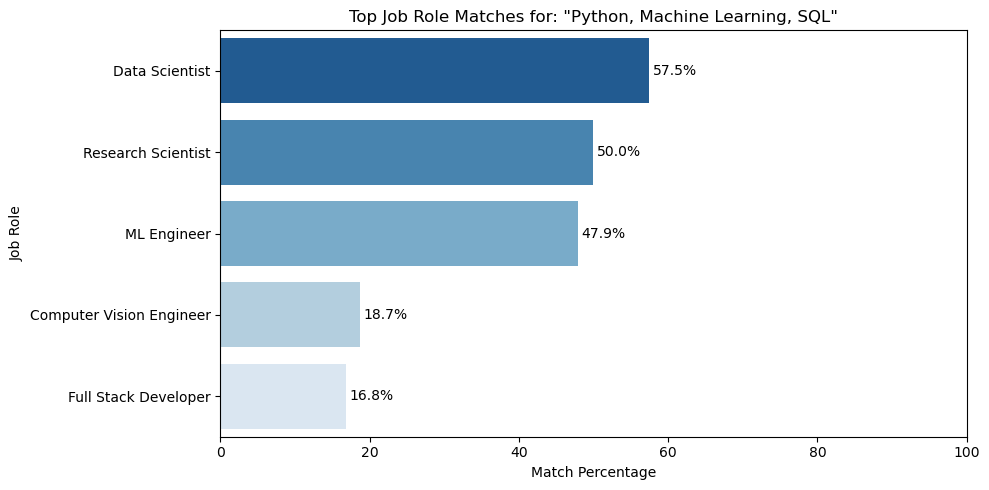

In [9]:
# Test input
user_skills = "Python, Machine Learning, SQL"
results = recommend(user_skills, top_n=5)

print(f"Input Skills: {user_skills}\n")
print(results.to_string(index=False))

# Bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=results, x='Match %', y='Job Role', hue='Job Role', palette='Blues_r', legend=False)
plt.title(f'Top Job Role Matches for: "{user_skills}"')
plt.xlabel('Match Percentage')
plt.ylabel('Job Role')
plt.xlim(0, 100)
for i, v in enumerate(results['Match %']):
    plt.text(v + 0.5, i, f'{v}%', va='center')
plt.tight_layout()
plt.show()

In [8]:
test_cases = [
    "Python, Machine Learning, SQL",
    "Docker, Kubernetes, AWS",
    "JavaScript, React, Node.js",
    "Python, NLP, Transformers",
    "Solidity, Ethereum, Web3"
]

for skills in test_cases:
    results = recommend(skills, top_n=3)
    print(f"\nSkills: {skills}")
    print(f"  1. {results.iloc[0]['Job Role']} ({results.iloc[0]['Match %']}%)")
    print(f"  2. {results.iloc[1]['Job Role']} ({results.iloc[1]['Match %']}%)")
    print(f"  3. {results.iloc[2]['Job Role']} ({results.iloc[2]['Match %']}%)")


Skills: Python, Machine Learning, SQL
  1. Data Scientist (57.5%)
  2. Research Scientist (50.0%)
  3. ML Engineer (47.9%)

Skills: Docker, Kubernetes, AWS
  1. DevOps Engineer (44.3%)
  2. Cloud Architect (43.0%)
  3. ML Engineer (27.8%)

Skills: JavaScript, React, Node.js
  1. Full Stack Developer (63.3%)
  2. Backend Developer (33.0%)
  3. Frontend Developer (25.0%)

Skills: Python, NLP, Transformers
  1. NLP Engineer (43.1%)
  2. AI Engineer (21.8%)
  3. Full Stack Developer (5.3%)

Skills: Solidity, Ethereum, Web3
  1. Blockchain Developer (60.6%)
  2. Data Scientist (0.0%)
  3. ML Engineer (0.0%)
